In [51]:
#! pip install torchsummary
#! pip install pytorch-ignite
#! pip install torchsummary
#! pip install matplotlib.pyplot
#! pip install pandas
#! pip install numpy

NN Pytorch

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

from torchsummary import summary
from torch.nn.init import xavier_normal_
from torch.utils.data import TensorDataset, DataLoader

from ignite.metrics import MeanSquaredError, MeanAbsoluteError, Metric

In [53]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold, train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler

In [54]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchsummary import summary
from torch.utils.data import TensorDataset, DataLoader

from ignite.metrics import Accuracy, Loss
from ignite.engine import Engine, Events, create_supervised_trainer, create_supervised_evaluator

In [55]:
x_train = (pd.read_csv('/content/X_train_rating_no_out_regression.csv')).drop('Unnamed: 0', axis =1)
y_train = (pd.read_csv('/content/y_train_rating_no_out_regression.csv')).drop('Unnamed: 0', axis =1)

x_test = (pd.read_csv('/content/X_test_rating_regression.csv')).drop('Unnamed: 0', axis =1)
y_test = (pd.read_csv('/content/y_test_rating_regression.csv')).drop('Unnamed: 0', axis =1)

In [56]:
y_train = y_train['averageRating']
y_test = y_test['averageRating']

In [57]:
# log transformation delle seguenti colonne: runtimeminutes, numvotes, totalcredits, userrewtotal, totalmedia
cols = ['runtimeMinutes', 'numVotes', 'totalCredits', 'userReviewsTotal', 'totalMedia']

for col in cols:
    x_train[col] = np.log1p(x_train[col])
    x_test[col] = np.log1p(x_test[col])

In [58]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [59]:
folds = KFold(n_splits=5, shuffle = True, random_state= 42)

## Costruzione rete

In [60]:
x_train_split, x_val, y_train_split, y_val = train_test_split(x_scaled, y_train, test_size=0.3, random_state=42)

In [61]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [62]:
x_train_tensor = torch.tensor(x_train_split, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train_split.values, dtype=torch.float32).to(device)

x_val_tensor = torch.tensor(x_val, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).to(device)

x_test_tensor = torch.tensor(x_test_scaled, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).to(device)

In [63]:
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
val_dataset = TensorDataset(x_val_tensor, y_val_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

In [64]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

In [76]:
class NNRegressor(nn.Module):

    def __init__(self, input_dim, hidden_size, output_size):
        super(NNRegressor, self).__init__()

        self.input_layer = nn.Linear(input_dim, hidden_size)
        self.hidden_layer = nn.Linear(hidden_size, hidden_size)
        self.output_layer = nn.Linear(hidden_size, output_size)

        self.relu = nn.ReLU()

    # Applicazione delle funzioni di attivazione per ogni strato
    def forward(self, x):
        x = self.relu(self.input_layer(x))
        x = self.relu(self.hidden_layer(x))
        x = self.output_layer(x)

        return x.squeeze()


In [77]:
input_size = x_scaled.shape[1] # ci devono essere tanti neuroni quante istanze da considerare
hidden_size = 32
output_size = 1 # settato ad 1 perché l'output della regressione deve essere un singolo valore

In [78]:
from ignite.handlers import EarlyStopping, ModelCheckpoint
from ignite.contrib.handlers import global_step_from_engine
from ignite.engine import Engine, Events, create_supervised_trainer, create_supervised_evaluator

In [79]:
model = NNRegressor(input_size, hidden_size, output_size).to(device)
optimizer = optim.Adam(model.parameters(), lr= 0.01)
criterion = nn.MSELoss()

In [80]:
class R2Score(Metric):
    def __init__(self, output_transform=lambda x: x, device=None):
        super(R2Score, self).__init__(output_transform=output_transform, device=device)

    def reset(self):
        self._sum_squared_error = 0.0
        self._sum_abs_error = 0.0
        self._sum_target = 0.0
        self._sum_squared_target = 0.0
        self._num_examples = 0

    def update(self, output):
        y_pred, y_true = output
        y_pred = y_pred.detach().flatten()
        y_true = y_true.detach().flatten()

        # Move to CPU to save GPU memory
        y_pred = y_pred.cpu()
        y_true = y_true.cpu()

        # Update running statistics
        self._sum_squared_error += torch.sum((y_true - y_pred) ** 2).item()
        self._sum_target += torch.sum(y_true).item()
        self._sum_squared_target += torch.sum(y_true ** 2).item()
        self._num_examples += y_true.size(0)

    def compute(self):
        if self._num_examples == 0:
            return 0.0

        mean_target = self._sum_target / self._num_examples
        total_sum_squares = self._sum_squared_target - self._num_examples * mean_target ** 2

        if total_sum_squares == 0:
            return 1.0 if self._sum_squared_error == 0 else 0.0

        r2 = 1 - (self._sum_squared_error / total_sum_squares)
        return r2

In [81]:
trainer = create_supervised_trainer(model, optimizer, criterion, device = device)

In [82]:
val_metrics = {"mean_squared_error": MeanSquaredError(device=device), "mean_absolute_error": MeanAbsoluteError(device=device), 'r2': R2Score(device=device)}

# ignite train and validation evaluators
train_evaluator = create_supervised_evaluator(model, metrics=val_metrics, device=device)
val_evaluator = create_supervised_evaluator(model, metrics=val_metrics, device=device)

training_history = {'mean_squared_error':[],'mean_absolute_error':[], 'r2' :[] }
validation_history = {'mean_squared_error':[],'mean_absolute_error':[], 'r2': []}

In [83]:
log_interval = 200

@trainer.on(Events.ITERATION_COMPLETED(every=log_interval))
def log_training_loss(engine):
    print(f"Epoch[{engine.state.epoch}], Iter[{engine.state.iteration}] Loss: {engine.state.output:.2f}")

# after a training epoch, computes training and validation metrics (train_eval on train_loader and val_eval on val_loader)
@trainer.on(Events.EPOCH_COMPLETED)
def log_training_results(trainer):
    train_evaluator.run(train_loader)
    metrics = train_evaluator.state.metrics
    training_history['mean_squared_error'].append(metrics['mean_squared_error'])
    training_history['mean_absolute_error'].append(metrics['mean_absolute_error'])
    training_history['r2'].append(metrics['r2'])
    print(f"Training Results - Epoch[{trainer.state.epoch}] MeanSquaredError: {metrics['mean_squared_error']:.2f} MeanAbsoluteError: {metrics['mean_absolute_error']:.2f} R2: {metrics['r2']:.2f}")

@trainer.on(Events.EPOCH_COMPLETED)
def log_validation_results(trainer):
    val_evaluator.run(val_loader)
    metrics = val_evaluator.state.metrics
    validation_history['mean_squared_error'].append(metrics['mean_squared_error'])
    validation_history['mean_absolute_error'].append(metrics['mean_absolute_error'])
    validation_history['r2'].append(metrics['r2'])
    print(f"Validation Results - Epoch[{trainer.state.epoch}] MeanSquaredError: {metrics['mean_squared_error']:.2f} MeanAbsoluteError: {metrics['mean_absolute_error']:.2f} R2: {metrics['r2']:.2f}")

    torch.cuda.empty_cache() if torch.cuda.is_available() else None

In [84]:
def score_function(engine):
    y_pred, y_true = engine.state.output
    return r2_score(y_true.cpu().numpy(), y_pred.cpu().numpy())

In [86]:
handler = EarlyStopping(patience = 50, score_function=score_function, trainer = trainer)

checkpoint = ModelCheckpoint(dirname='models',
    filename_prefix='best_NOREG',
    n_saved=1,
    create_dir=True,
    global_step_transform=global_step_from_engine(trainer))

val_evaluator.add_event_handler(Events.EPOCH_COMPLETED, handler)
val_evaluator.add_event_handler(Events.EPOCH_COMPLETED, checkpoint, {'model': model})

In [87]:
trainer.run(train_loader, max_epochs=300)

Epoch[1], Iter[200] Loss: 1.56
Epoch[1], Iter[400] Loss: 2.32
Epoch[1], Iter[600] Loss: 0.98
Epoch[1], Iter[800] Loss: 0.90
Epoch[1], Iter[1000] Loss: 1.30
Epoch[1], Iter[1200] Loss: 1.08
Epoch[1], Iter[1400] Loss: 3.04
Epoch[1], Iter[1600] Loss: 1.66
Epoch[1], Iter[1800] Loss: 1.19
Epoch[1], Iter[2000] Loss: 1.61
Epoch[1], Iter[2200] Loss: 5.17
Epoch[1], Iter[2400] Loss: 1.05
Epoch[1], Iter[2600] Loss: 0.90
Epoch[1], Iter[2800] Loss: 1.45
Epoch[1], Iter[3000] Loss: 2.07
Epoch[1], Iter[3200] Loss: 1.29
Epoch[1], Iter[3400] Loss: 0.84
Epoch[1], Iter[3600] Loss: 1.68
Epoch[1], Iter[3800] Loss: 0.65
Epoch[1], Iter[4000] Loss: 1.06
Epoch[1], Iter[4200] Loss: 0.38
Epoch[1], Iter[4400] Loss: 1.91
Training Results - Epoch[1] MeanSquaredError: 1.34 MeanAbsoluteError: 0.87 R2: 0.26
Validation Results - Epoch[1] MeanSquaredError: 1.34 MeanAbsoluteError: 0.87 R2: 0.24
Epoch[2], Iter[4600] Loss: 1.08
Epoch[2], Iter[4800] Loss: 0.45
Epoch[2], Iter[5000] Loss: 1.36
Epoch[2], Iter[5200] Loss: 2.12
Ep

2025-08-20 16:27:11,282 ignite.handlers.early_stopping.EarlyStopping INFO: EarlyStopping: Stop training


Validation Results - Epoch[58] MeanSquaredError: 1.26 MeanAbsoluteError: 0.82 R2: 0.29


State:
	iteration: 258042
	epoch: 58
	epoch_length: 4449
	max_epochs: 300
	output: 0.3831768333911896
	batch: <class 'list'>
	metrics: <class 'dict'>
	dataloader: <class 'torch.utils.data.dataloader.DataLoader'>
	seed: <class 'NoneType'>
	times: <class 'dict'>

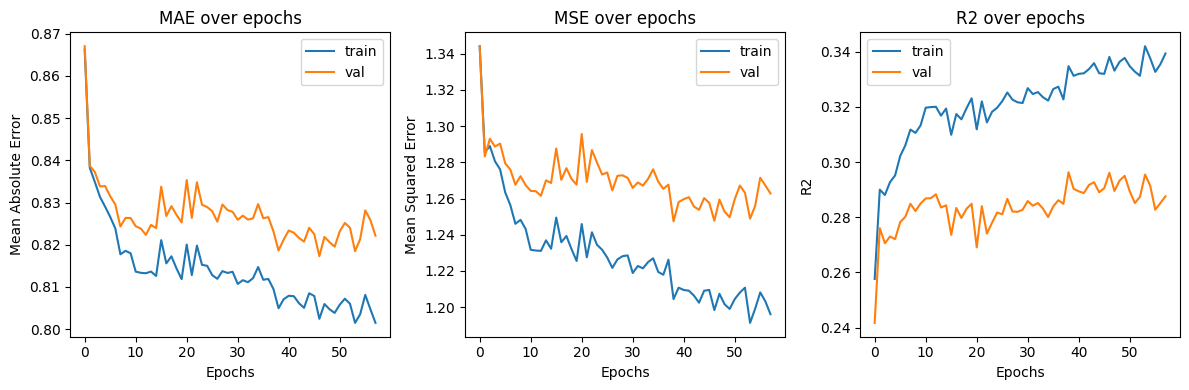

In [88]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 4))

# Plot MAE
axes[0].plot(training_history['mean_absolute_error'], label='train')
axes[0].plot(validation_history['mean_absolute_error'], label='val')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Mean Absolute Error')
axes[0].set_title('MAE over epochs')
axes[0].legend()

# Plot MSE
axes[1].plot(training_history['mean_squared_error'], label='train')
axes[1].plot(validation_history['mean_squared_error'], label='val')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Mean Squared Error')
axes[1].set_title('MSE over epochs')
axes[1].legend()

# Plot R2
axes[2].plot(training_history['r2'], label='train')
axes[2].plot(validation_history['r2'], label='val')
axes[2].set_xlabel('Epochs')
axes[2].set_ylabel('R2')
axes[2].set_title('R2 over epochs')
axes[2].legend()

fig.tight_layout()
plt.show()